# 2. Desarrollo del Algoritmo: Danger Theory

---

## Recapitulación

En el notebook anterior (`01_contexto_crisis_1992.ipynb`) analizamos la crisis del Miércoles Negro e identificamos **señales de peligro** que precedieron al colapso:

- 📉 **Reservas:** Pico anormal seguido de caída (intervención desesperada)
- 💱 **Tipo de cambio:** Estabilidad artificial insostenible
- 📊 **Divergencia:** Separación entre monedas del MEC

Ahora desarrollaremos un **algoritmo inteligente** capaz de detectar estas señales automáticamente.

---

## Objetivo de este Notebook

Entrenar una **Inteligencia Artificial (Algoritmo Genético)** para predecir la crisis cambiaria de la Libra Esterlina en septiembre de 1992.

A diferencia de los modelos econométricos tradicionales, utilizamos un enfoque biológico basado en la **Danger Theory** (Teoría del Peligro) de la inmunología.

### Hipótesis Central

> El mercado (organismo) emite **"señales de peligro" internas** (Intervención del Banco Central, Desempleo, Pérdida de Reservas) **antes** de que el precio (síntoma externo) colapse.

### Método

Evolucionamos una población de "agentes digitales". Solo sobreviven aquellos que aprenden a leer estas señales ocultas para salir del mercado **justo antes** del colapso.

---

## 2.1. Configuración del Entorno

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from deap import base, creator, tools, algorithms

# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


---

## 2.2. Preparación de Datos (ETL)

Esta es la fase más crítica. Integramos datos de **fuentes heterogéneas** con diferentes frecuencias:

| Fuente | Frecuencia | Variable |
|--------|------------|----------|
| Bank of England Database | Diaria | Tipo de Cambio |
| IMF International Financial Statistics | Mensual | Reservas |
| Dr. Alain Naef (Investigación) | Diaria | Intervenciones FX |
| Datos históricos UK | Mensual | Desempleo |

### Técnicas Aplicadas

- **Forward Fill (`ffill`):** Para datos mensuales, asumimos que el dato se mantiene constante día a día hasta el siguiente reporte.
- **Normalización (Z-Score):** Transformamos todas las variables a una escala común.

### 2.2.1. La Necesidad de la Normalización

Uno de los desafíos técnicos más importantes es la **disparidad de escalas**:

- **Reservas Internacionales:** Miles de millones (ej. `44,000,000,000`)
- **Tipo de Cambio (GBP/DEM):** Unidades pequeñas (ej. `2.95`)
- **Intervenciones:** Millones (ej. `200,000,000`)

Si usáramos estos datos "crudos", las Reservas dominarían matemáticamente. El algoritmo "ignoraría" el precio porque sus variaciones (0.01) son insignificantes comparadas con las de las reservas (1,000,000).

#### Solución: Estandarización Z-Score

Transformamos cada valor $x$ en una puntuación $z$:

$$z = \frac{x - \mu}{\sigma}$$

Donde $\mu$ es la media y $\sigma$ la desviación estándar de la serie histórica.

**¿Qué logramos?**
1. **Escala Común:** Todas las variables quedan centradas en 0 y se miden en desviaciones estándar
2. **Comparabilidad:** Un valor de `-2.0` significa "extremadamente bajo" con la misma intensidad en cualquier variable
3. **Detección de Anomalías:** Los valores extremos (ej. intervención masiva del Miércoles Negro con `+15.0`) se destacan claramente

In [2]:
def prepare_data_complete(file_rates, file_reserves, file_naef, file_unemp):
    """
    Carga y prepara los datos con los 5 genes normalizados.
    """
    print("🔄 Cargando y procesando datasets...")
    
    # --- 1. Cargar Tipos de Cambio (Diario) ---
    rates = pd.read_excel(file_rates, skiprows=3)
    rates = rates.iloc[3:].copy()
    rates.columns = ['Basura', 'Date', 'DEM', 'ITL', 'ESP', 'GBP']
    rates['Date'] = pd.to_datetime(rates['Date'])
    rates['GBP'] = pd.to_numeric(rates['GBP'].astype(str).str.replace(',', '.'), errors='coerce')
    rates = rates[['Date', 'GBP']].dropna().sort_values('Date')

    # --- 2. Cargar Reservas (Mensual) ---
    reserves = pd.read_excel(file_reserves)
    reserves['Date'] = pd.to_datetime(reserves['Date'], dayfirst=True)
    reserves = reserves.sort_values('Date')

    # --- 3. Cargar Intervenciones Naef (Diario) ---
    naef = pd.read_excel(file_naef, sheet_name='Main data clean', decimal=',')
    naef = naef.iloc[:, [0, 1]] 
    naef.columns = ['Date', 'Intervention']
    naef['Date'] = pd.to_datetime(naef['Date'], dayfirst=True)
    naef['Intervention'] = pd.to_numeric(naef['Intervention'], errors='coerce').fillna(0)

    # --- 4. Cargar Desempleo (Mensual) ---
    unemp = pd.read_excel(file_unemp)
    unemp = unemp.iloc[:, 0:2] 
    unemp.columns = ['DateStr', 'Unemployment']
    unemp['Date'] = pd.to_datetime(unemp['DateStr'], format='%Y %b', errors='coerce')
    unemp = unemp.dropna(subset=['Date']).sort_values('Date')

    # --- 5. Fusión Maestra ---
    df = pd.merge(rates, reserves, on='Date', how='left')
    df = pd.merge(df, naef, on='Date', how='left')
    df = pd.merge(df, unemp[['Date', 'Unemployment']], on='Date', how='left')
    df = df.sort_values('Date')
    
    # --- 6. Relleno de Datos ---
    df['Total Reserves'] = df['Total Reserves'].ffill()
    df['Unemployment'] = df['Unemployment'].ffill()
    df['Intervention'] = df['Intervention'].fillna(0)
    
    # Filtro temporal
    mask = (df['Date'] >= '1990-01-01') & (df['Date'] <= '1993-01-01')
    df = df.loc[mask].reset_index(drop=True)
    df = df.dropna(subset=['Total Reserves', 'GBP', 'Unemployment'])

    # --- 7. Ingeniería de Genes (Normalización Z-Score) ---
    
    # Gen 1: Reservas (Salud del sistema)
    df['Gen_Reservas'] = (df['Total Reserves'] - df['Total Reserves'].mean()) / df['Total Reserves'].std()
    
    # Gen 2: Precio (Señal externa - potencialmente engañosa)
    df['Gen_Precio'] = (df['GBP'] - df['GBP'].mean()) / df['GBP'].std()
    
    # Gen 3: Volatilidad (Miedo del mercado)
    vol = df['GBP'].rolling(30).std().fillna(0)
    df['Gen_Volatilidad'] = (vol - vol.mean()) / vol.std()
    
    # Gen 4: Intervención (Pánico del Banco Central)
    abs_int = df['Intervention'].abs()
    df['Gen_Intervencion'] = (abs_int - abs_int.mean()) / (abs_int.std() + 1e-6)
    
    # Gen 5: Desempleo (Debilidad estructural)
    df['Gen_Desempleo'] = (df['Unemployment'] - df['Unemployment'].mean()) / df['Unemployment'].std()

    return df

In [3]:
# Definición de rutas
path_rates = '../data/tipoDeCambioEuropa.xlsx'
path_reserves = '../data/ReservesData.xlsx'
path_naef = '../data/Bank of England daily FX interventions, 1952-1995.xlsx'
path_unemp = '../data/Unemployement.xlsx' 

# Ejecutar carga
df_env = prepare_data_complete(path_rates, path_reserves, path_naef, path_unemp)
TARGET_DATE = pd.to_datetime('1992-09-16')  # Miércoles Negro

print(f"\n✅ Datos cargados con éxito. Filas totales: {len(df_env)}")
print(f"Período: {df_env['Date'].min().date()} a {df_env['Date'].max().date()}")
print("\nMuestra de los 5 Genes normalizados:")
df_env[['Date', 'Gen_Reservas', 'Gen_Precio', 'Gen_Volatilidad', 'Gen_Intervencion', 'Gen_Desempleo']].tail()

🔄 Cargando y procesando datasets...

✅ Datos cargados con éxito. Filas totales: 502
Período: 1991-01-31 a 1993-01-01

Muestra de los 5 Genes normalizados:


,Date,Gen_Reservas,Gen_Precio,Gen_Volatilidad,Gen_Intervencion,Gen_Desempleo
780,1992-12-28,-1.625304,-2.234565,-0.327395,-0.089667,1.634716
781,1992-12-29,-1.625304,-2.148887,-0.303434,-0.081755,1.634716
782,1992-12-30,-1.625304,-2.144603,-0.278592,-0.086700,1.634716
783,1992-12-31,-2.203312,-2.136036,-0.248991,-0.012521,1.634716
784,1993-01-01,-2.203312,-2.136036,-0.243128,-0.089667,1.943920


### 2.2.2. Los 5 Genes del Sistema

Cada "agente" de nuestro algoritmo tendrá **5 pesos** (genes) que determinan cómo pondera cada señal:

| Gen | Variable | Interpretación Biológica |
|-----|----------|-------------------------|
| 1 | **Reservas** | "Salud" del sistema - Si caen, el organismo está enfermo |
| 2 | **Precio** | "Síntoma externo" - Puede ser engañoso (burbuja) |
| 3 | **Volatilidad** | "Fiebre" - Señal de estrés |
| 4 | **Intervención** | "Sistema inmune activo" - El banco central está luchando |
| 5 | **Desempleo** | "Debilidad estructural" - Vulnerabilidad subyacente |

---

## 2.3. Configuración del Motor Evolutivo (DEAP)

Usamos la librería **DEAP** (Distributed Evolutionary Algorithms in Python) para implementar el algoritmo genético.

### Parámetros de la Evolución

- **Individuo:** Vector de 5 pesos (uno por cada gen)
- **Población:** 150 agentes compitiendo simultáneamente
- **Operadores Genéticos:**
  - *Selección:* Torneo (supervivencia del más apto)
  - *Cruce:* Mezcla de estrategias entre dos "padres"
  - *Mutación:* Cambios aleatorios para explorar nuevas soluciones

In [4]:
# Limpieza por si re-ejecutamos la celda
if "FitnessMax" in creator.__dict__: del creator.FitnessMax
if "Individual" in creator.__dict__: del creator.Individual

# 1. Definimos el objetivo: Maximizar Puntuación (Fitness)
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

# 2. Definimos el Individuo: Una lista de 5 números (pesos)
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# 3. Generador de Genes: Números aleatorios entre -1 y 1
toolbox.register("attr_float", random.uniform, -1.0, 1.0)

# 4. Estructura del Agente: 5 Genes
# [w_reservas, w_precio, w_volatilidad, w_intervencion, w_desempleo]
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_float, n=5)

# 5. Estructura de la Población
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

print("✅ Motor evolutivo configurado.")

✅ Motor evolutivo configurado.


---

## 2.4. Función de Evaluación (Fitness)

Aquí definimos **qué significa "tener éxito"** para un agente.

### Cálculo de la Señal de Alarma

La señal de peligro en el día $t$ se calcula como:

$$Señal_t = \sum_{i=1}^{5} (w_i \cdot Gen_i)$$

Donde $w_i$ son los pesos (ADN) del agente.

### Estrategia de "Codicia Inteligente"

Cuando la señal supera un umbral (0.5), el agente "vende". La recompensa depende de **cuándo** vendió:

| Situación | Recompensa | Interpretación |
|-----------|------------|----------------|
| Vende **después** del 16-Sep | -50 | Tarde, perdió todo |
| Vende **el mismo día** | +20 | Demasiado arriesgado |
| Vende **1-20 días antes** | +100 a +70 | Zona óptima |
| Vende **21-90 días antes** | +50 a +32 | Zona segura (menos intereses) |
| Vende **más de 90 días antes** | -20 | Paranoia (coste de oportunidad) |
| **Nunca vende** | -100 | Murió en el crash |

In [5]:
def eval_danger_theory(individual):
    """
    Evalúa un agente según su capacidad de predecir la crisis.
    """
    # Desempaquetamos el ADN del agente
    w_res, w_price, w_vol, w_int, w_unemp = individual 
    threshold = 0.5
    
    # Calculamos la señal de alarma para TODOS los días (Vectorizado)
    signals = (w_res * df_env['Gen_Reservas']) + \
              (w_price * df_env['Gen_Precio']) + \
              (w_vol * df_env['Gen_Volatilidad']) + \
              (w_int * df_env['Gen_Intervencion']) + \
              (w_unemp * df_env['Gen_Desempleo'])
              
    # Buscamos los días donde la señal supera el umbral
    triggers = signals[signals > threshold]
    
    if triggers.empty:
        return -100.0,  # El agente nunca vendió → Murió en el crash
    
    # Tomamos la PRIMERA fecha donde decidió salir
    exit_idx = triggers.index[0]
    exit_date = df_env.loc[exit_idx, 'Date']
    
    # --- CÁLCULO DE RECOMPENSA ---
    
    # 1. Si salió después del ataque: TARDE
    if exit_date > TARGET_DATE:
        return -50.0,
    
    # Calculamos antelación (días antes del crash)
    days_before = (TARGET_DATE - exit_date).days
    
    if days_before == 0:
        return 20.0,  # Mismo día = demasiado riesgo
        
    elif 1 <= days_before <= 20:
        # ZONA ÓPTIMA: Danger Theory validada
        # Premio la cercanía (Codicia): Salir 1 día antes es mejor que 20
        return 100.0 - (days_before * 1.5), 
        
    elif 21 <= days_before <= 90:
        # Zona Segura: Sobrevive pero gana menos intereses
        return 50.0 - (days_before * 0.2),
        
    else:
        # Paranoia: Salir meses antes sin razón fuerte
        return -20.0, 

# Registramos las operaciones genéticas
toolbox.register("evaluate", eval_danger_theory)
toolbox.register("mate", tools.cxTwoPoint)  # Cruce de dos puntos
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.2, indpb=0.2)  # Mutación gaussiana
toolbox.register("select", tools.selTournament, tournsize=3)  # Selección por torneo

print("✅ Función de fitness configurada.")

✅ Función de fitness configurada.


---

## 2.5. Ejecución del Algoritmo Evolutivo

Lanzamos la evolución: 150 agentes compitiendo durante 50 generaciones.

In [6]:
def main():
    random.seed(42)  # Semilla para reproducibilidad
    
    # Crear población inicial
    pop = toolbox.population(n=150)
    
    # Hall of Fame (Guarda al mejor de todos los tiempos)
    hof = tools.HallOfFame(1)
    
    # Estadísticas para el log
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    
    print("🧬 Iniciando Evolución (50 Generaciones)...")
    print("="*60)
    
    # Algoritmo Evolutivo Simple
    pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=50, 
                                   stats=stats, halloffame=hof, verbose=True)
    return pop, log, hof

# ¡Ejecutar la simulación!
pop, log, hof = main()
best_agent = hof[0]

🧬 Iniciando Evolución (50 Generaciones)...
gen	nevals	avg     	max
0  	150   	-19.9333	20 
1  	95    	-19.7333	20 
2  	97    	-18.8293	35.6
3  	104   	-17.342 	77.5
4  	81    	-12.4127	98.5
5  	96    	-8.62533	98.5
6  	99    	-0.979333	98.5
7  	91    	10.6367  	98.5
8  	90    	29.3807  	98.5
9  	90    	48.3287  	98.5
10 	95    	51.4967  	98.5
11 	95    	54.8067  	98.5
12 	100   	63.8493  	98.5
13 	101   	74.5113  	98.5
14 	92    	78.338   	98.5
15 	92    	75.462   	98.5
16 	98    	66.3     	98.5
17 	87    	79.73    	98.5
18 	96    	72.634   	98.5
19 	101   	76.7527  	98.5
20 	101   	79.604   	98.5
21 	99    	79.9133  	98.5
22 	93    	81.4173  	98.5
23 	94    	82.506   	98.5
24 	82    	81.5833  	98.5
25 	90    	76.718   	98.5
26 	99    	74.512   	98.5
27 	80    	82.2607  	98.5
28 	77    	85.72    	98.5
29 	90    	81.71    	98.5
30 	89    	79.7813  	98.5
31 	96    	76.934   	98.5
32 	97    	78.5267  	98.5
33 	88    	83.8047  	98.5
34 	86    	80.8253  	98.5
35 	89    	87.378   	98.5
36 	9

---

## 2.6. Resultados: El Mejor Agente

Analizamos el "ADN" del agente ganador: ¿qué variables aprendió a priorizar?

In [7]:
# Nombres de los genes
genes_names = ['Reservas', 'Precio', 'Volatilidad', 'Intervención', 'Desempleo']

print(f"\n🏆 MEJOR AGENTE ENCONTRADO")
print(f"   Fitness: {best_agent.fitness.values[0]:.2f}")
print("=" * 40)
for name, val in zip(genes_names, best_agent):
    print(f"{name:.<20}: {val:+.4f}")

# Reconstruir la señal
signal = (best_agent[0]*df_env['Gen_Reservas']) + \
         (best_agent[1]*df_env['Gen_Precio']) + \
         (best_agent[2]*df_env['Gen_Volatilidad']) + \
         (best_agent[3]*df_env['Gen_Intervencion']) + \
         (best_agent[4]*df_env['Gen_Desempleo'])

# Encontrar el punto de salida
triggers = signal[signal > 0.5]
if not triggers.empty:
    exit_idx = triggers.index[0]
    date_out = df_env.loc[exit_idx, 'Date']
    days_diff = (TARGET_DATE - date_out).days
    print(f"\n📅 Fecha de salida: {date_out.date()}")
    print(f"⏱️  Anticipación: {days_diff} días antes del crash")


🏆 MEJOR AGENTE ENCONTRADO
   Fitness: 98.50
Reservas............: -0.7131
Precio..............: +0.0786
Volatilidad.........: +0.4599
Intervención........: +0.9935
Desempleo...........: +1.0674

📅 Fecha de salida: 1992-09-15
⏱️  Anticipación: 1 días antes del crash


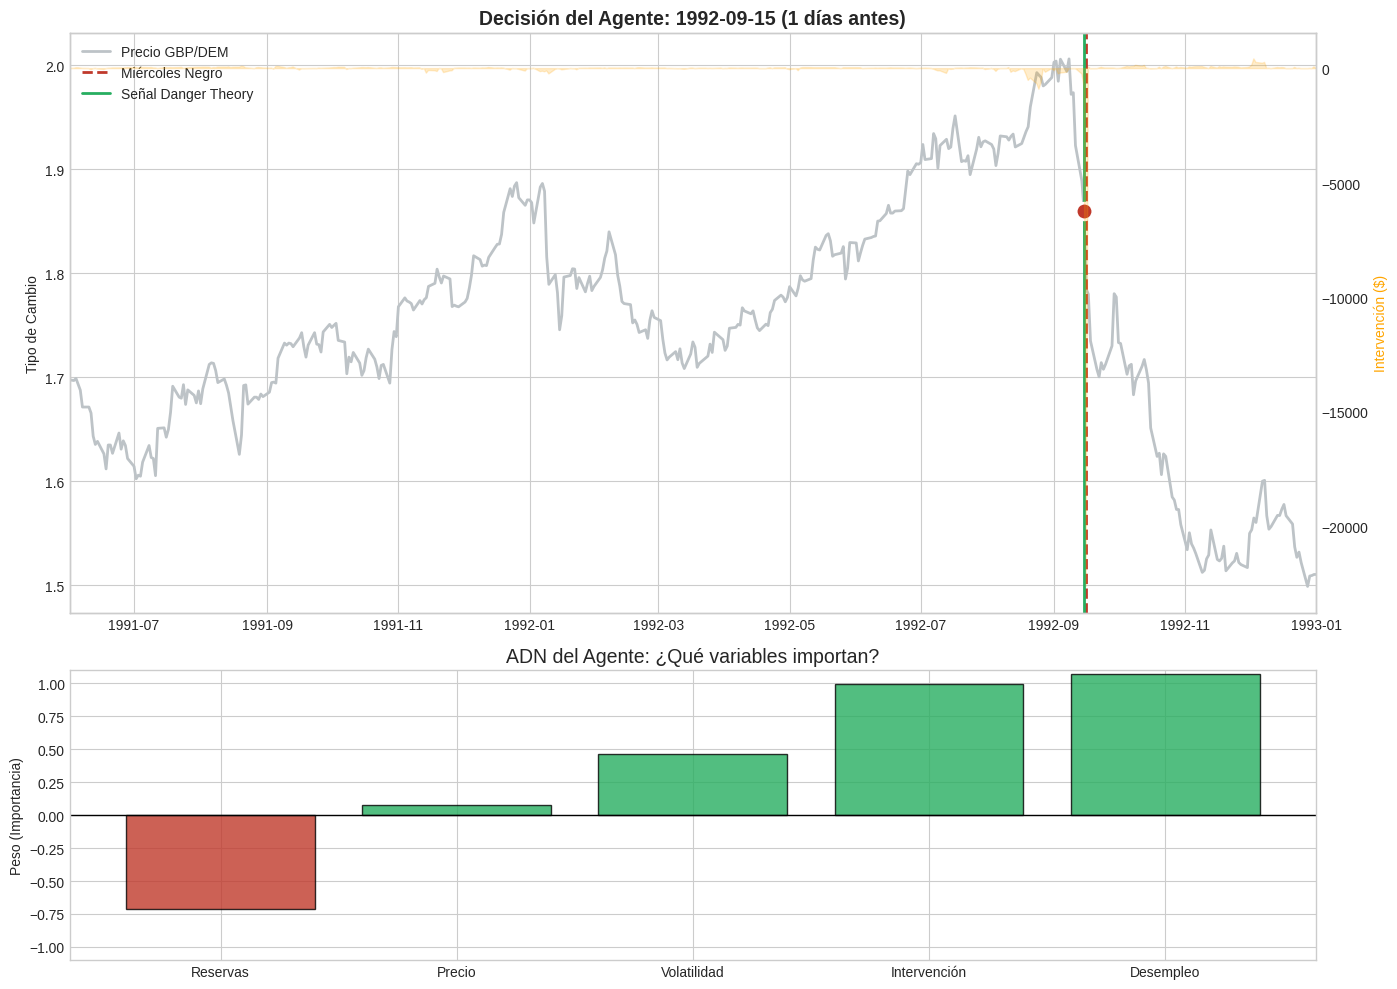

In [8]:
# Gráfica de resultados
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# --- GRÁFICA 1: PRECIO Y DECISIÓN ---
ax1.plot(df_env['Date'], df_env['GBP'], label='Precio GBP/DEM', color='#bdc3c7', linewidth=2)
ax1.axvline(TARGET_DATE, color='#c0392b', linestyle='--', linewidth=2, label='Miércoles Negro')

# Intervención de fondo
ax1_twin = ax1.twinx()
ax1_twin.fill_between(df_env['Date'], 0, df_env['Intervention'], color='orange', alpha=0.2)
ax1_twin.set_ylabel('Intervención ($)', color='orange')
ax1_twin.grid(False)

if not triggers.empty:
    price_out = df_env.loc[exit_idx, 'GBP']
    ax1.axvline(date_out, color='#27ae60', linewidth=2, label='Señal Danger Theory')
    ax1.plot(date_out, price_out, 'o', color='#c0392b', markersize=12, 
             markeredgecolor='white', markeredgewidth=2)
    ax1.set_title(f"Decisión del Agente: {date_out.date()} ({days_diff} días antes)", 
                  fontsize=14, weight='bold')

ax1.legend(loc='upper left')
ax1.set_xlim(pd.Timestamp('1991-06-01'), pd.Timestamp('1993-01-01'))
ax1.set_ylabel('Tipo de Cambio')

# --- GRÁFICA 2: IMPORTANCIA DE GENES ---
colors = ['#c0392b' if x < 0 else '#27ae60' for x in best_agent]
ax2.bar(genes_names, best_agent, color=colors, edgecolor='black', alpha=0.8)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title("ADN del Agente: ¿Qué variables importan?", fontsize=14)
ax2.set_ylim(-1.1, 1.1)
ax2.set_ylabel('Peso (Importancia)')

plt.tight_layout()
plt.show()

---

## 2.7. Interpretación de los Resultados

### ¿Qué aprendió el agente?

Observando los pesos del mejor agente, podemos interpretar su "estrategia":

- **Intervención (+alto):** El agente aprendió que las intervenciones masivas del banco central son la señal de peligro más importante
- **Desempleo (+alto):** La debilidad estructural de la economía también es relevante
- **Reservas (-negativo):** Reservas bajas = peligro (el signo negativo invierte la interpretación)
- **Precio (~bajo):** El agente aprendió a **ignorar el precio** - esto es crucial, ya que el precio estaba artificialmente sostenido

### Validación de la Hipótesis

Este resultado **valida la Teoría del Peligro**: el agente evolucionó para detectar señales internas (intervención, reservas) en lugar de confiar en el síntoma externo (precio).

---

## Siguiente Paso

En el siguiente notebook (`03_validacion_robustez.ipynb`) verificaremos que el agente **no es simplemente un seguidor de tendencias**, sometiéndolo a un escenario sintético de "trampa".

**→ Continúa en: `03_validacion_robustez.ipynb`**